### House Price : Advanced Regression Technique

#### Project Overview
Predict the final sale price of the residential homes in Ames, Lowa, using tabular features. This NoteBook the End-to-End Pipeline: 
EDA -> Data Preprocessing -> Feature Engineering -> Modeling -> Evalution.

In [ ]:
# Import the Libraries and Package and Config the Default notebook settings

# Importing core data manipulation Libraries
import pandas as pd
import numpy as np

# Importing data Visualizations Libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.inspection import permutation_importance


# Configure visualizations to display the inline in the notebook
%matplotlib inline

# Configuring to ignore the warnings for better output
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Set display options to see all columns
pd.set_option('display.max_columns', None)



# Data Loading and Data Inspection

In [2]:
data = pd.read_csv('./house_price_prediction_dataset.csv') 

In [3]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
shape = data.shape
print(f"Shape of the Data: {shape}")
print(f"Rows: {shape[0]}")
print(f"Columns: {shape[1]}")



Shape of the Data: (1460, 81)
Rows: 1460
Columns: 81


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### 2. Exploratory Data Analysis - EDA
##### 2.1 Target Variable Distribution

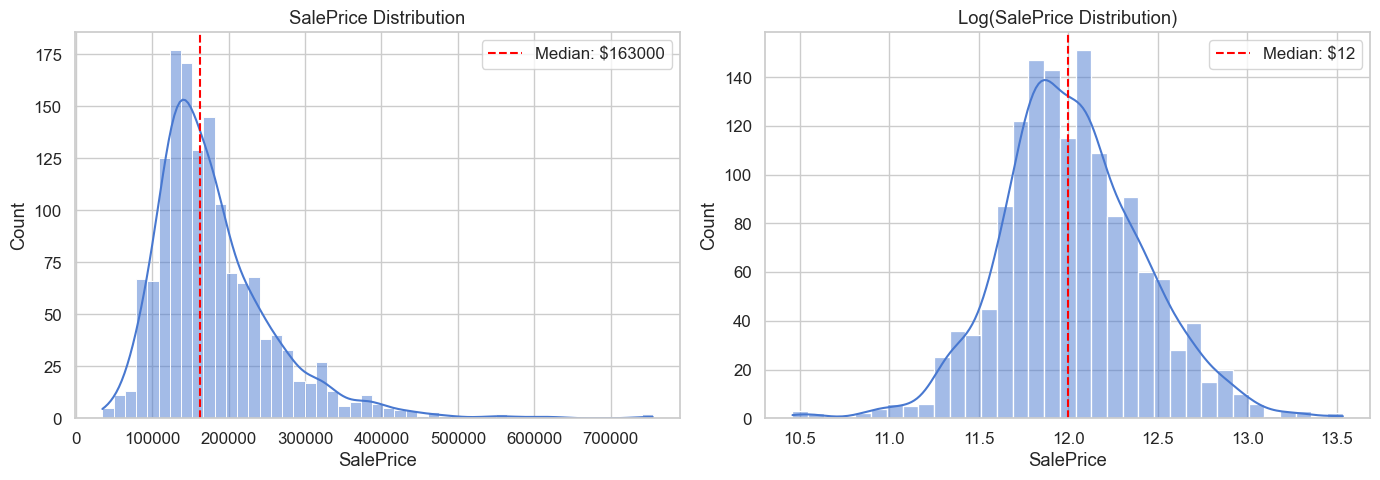

Skewness: 1.88
Kurtosys: 6.54
Log of the Sale Price skewness: 1.06


In [7]:
target = data.columns[-1] # we are getting the last column


sns.set_theme(style='whitegrid', palette='muted',font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# KDE - overlays a smooth curve (Kernel Density Estimate) to show the shape of the distribution.
sns.histplot(data[target], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')
axes[0].axvline(data[target].median(), color='red', ls='--', label=f"Median: ${data[target].median():.0f}")
axes[0].legend()

sns.histplot(np.log1p(data[target]), kde = True, ax = axes[1])
axes[1].set_title('Log(SalePrice Distribution)')
axes[1].axvline(np.log1p(data[target].median()), color='red', ls='--', label=f"Median: ${np.log1p(data[target].median()):.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Skewness: {data[target].skew():.2f}")
print(f"Kurtosys: {data[target].kurtosis():.2f}")
print(f"Log of the Sale Price skewness: {np.log1p(data[target].skew()):.2f}")


#### 2.2 Missing Value Analysis

,Count,Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


Number of Columns which has missing values: 19
Number of Columns which are > 40 %: 6


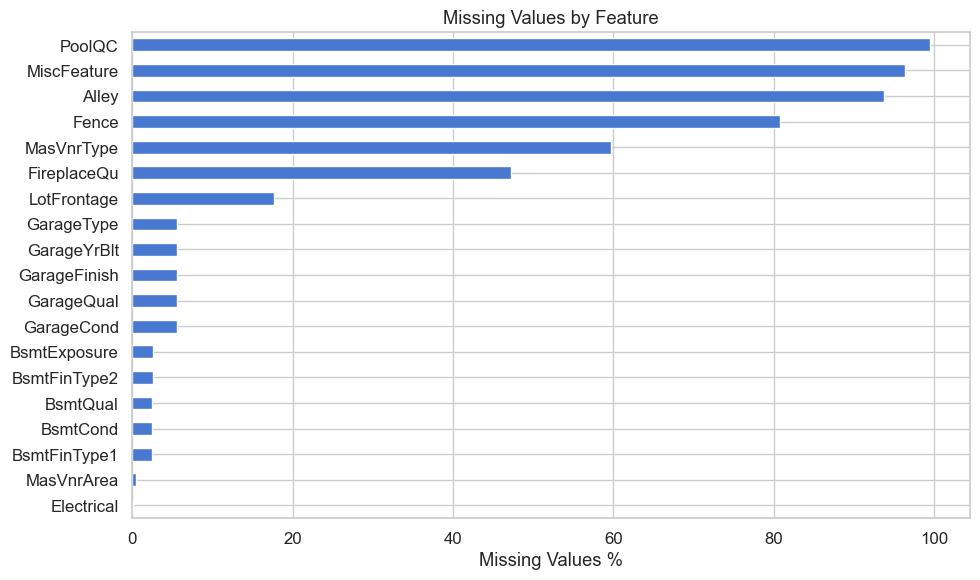

In [8]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_pct = round((missing / len(data) * 100),2)

df_missing_values = pd.DataFrame({'Count':missing, 'Percentage':missing_pct})
display(df_missing_values)
print(f"Number of Columns which has missing values: {len(df_missing_values)}")
print(f"Number of Columns which are > 40 %: {len(df_missing_values[df_missing_values['Percentage'] > 40])}")
fig, ax = plt.subplots(figsize=[10,6])
df_missing_values['Percentage'].plot.barh(ax = ax)
ax.set_xlabel("Missing Values %")
ax.set_title("Missing Values by Feature")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##### Key Points

- The Columns `PoolQc`, `MiscFeature`,`Alley`,`Fence`,`MasVnrType`.`FirePlaceQu`,`LotFrontage` these six columns has the null values more than 6 values.
- `LotFrontage` column has the ~ 18% Null Values and numeric column we can impurate with median value
- What is outlier: An outlier is a data point that is very far from the rest of the data.
- why median ? Medians are Robust to outlier.
- Robust: works reliably even when things go wrong
- Remaining Columns has missing values < 5% we can impute or fill them with values.

#### 2.3 Numeric Feature Positive Correlation with sale price

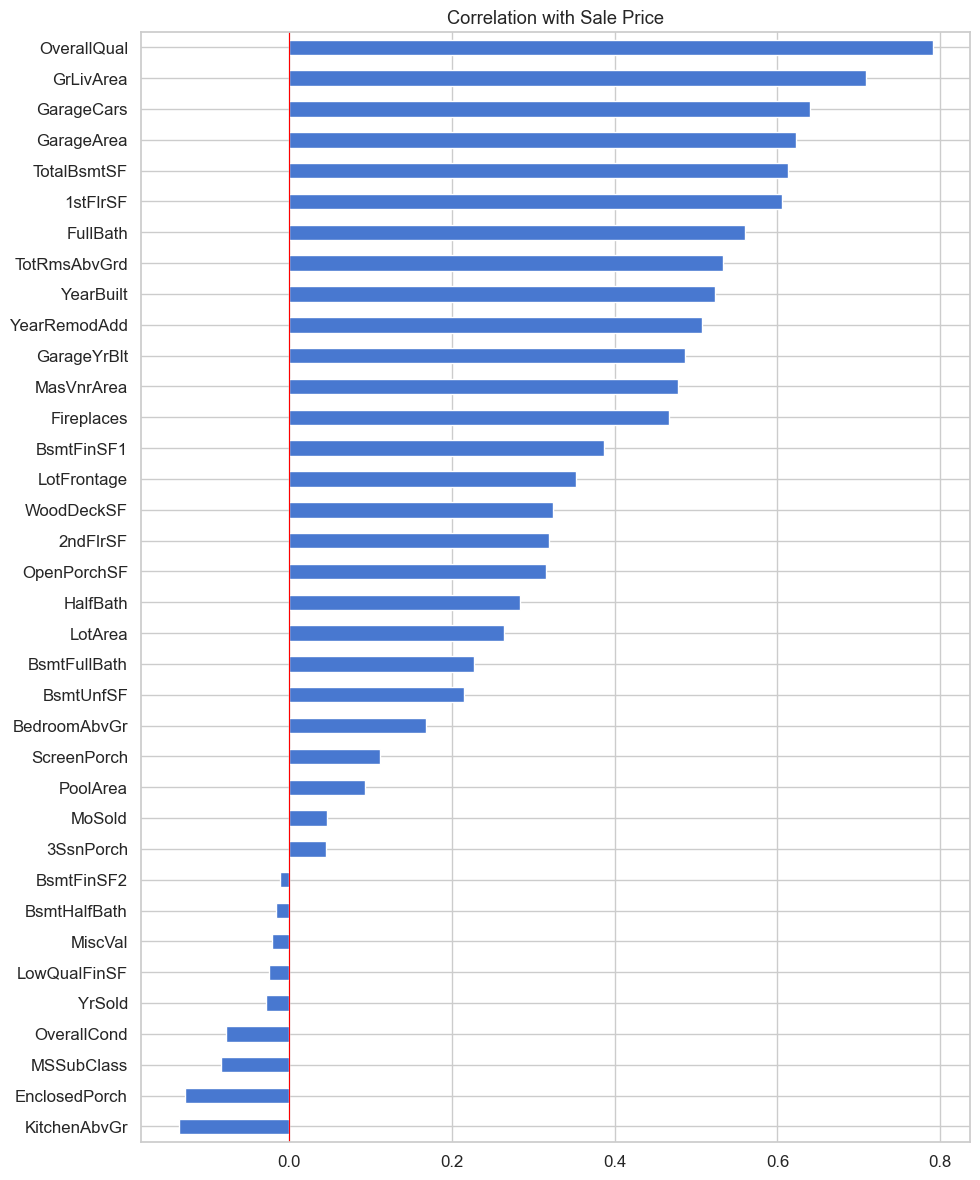

Top 10 positive correlations:


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [9]:
num_cols = data.select_dtypes(include='number').columns.to_list()
num_cols = [c for c in num_cols if c not in ('Id',)]

corr = data[num_cols].corr()
sals_corr = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize = (10, 12))
sals_corr.plot.barh(ax=ax)
ax.set_title("Correlation with Sale Price")
ax.axvline(0,color='red',lw=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 Correlations with sale price
print('Top 10 positive correlations:')
display(sals_corr.head(10))

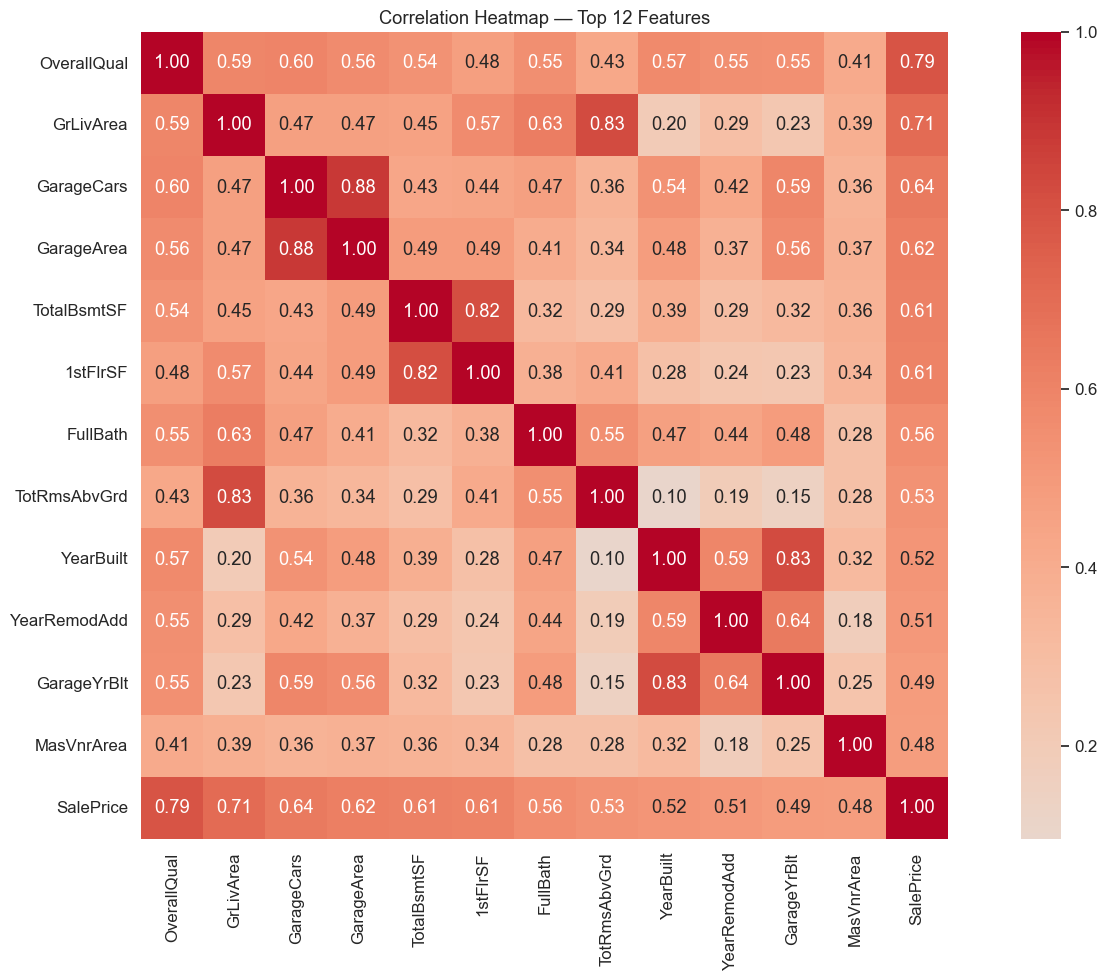

In [10]:
top_corr_cols = sals_corr.abs().sort_values(ascending=False).head(12).index.to_list()
top_corr_cols.append('SalePrice')
plt.figure(figsize=(15,10))
sns.heatmap(data[top_corr_cols].corr(),annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True)
plt.title("Correlation Heatmap — Top 12 Features")
plt.tight_layout()
plt.show()


#### 2.4 Key Bi-Variant Plots (Feature vs Sale Price)


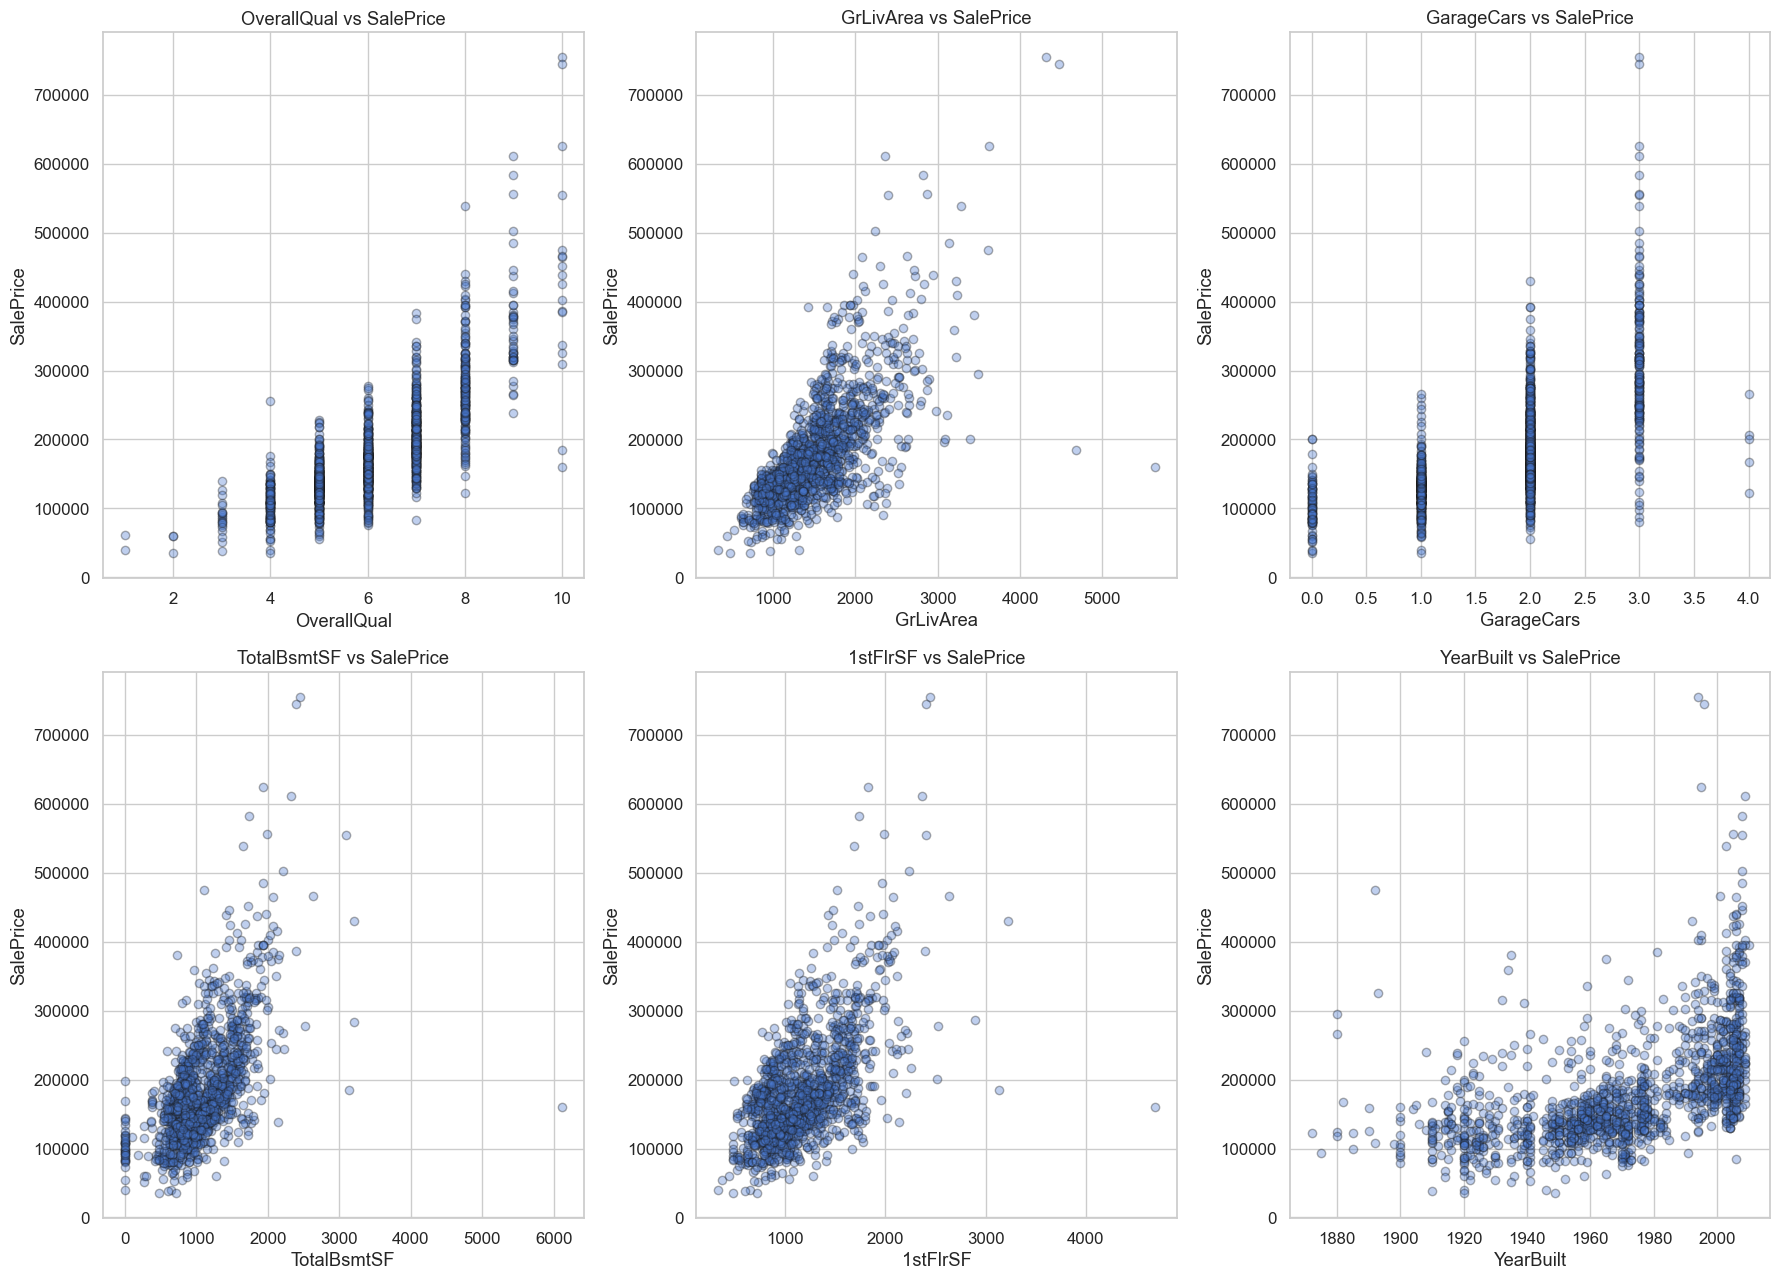

In [11]:
# Why the feature: This shows +ve realtionship with sale price target.
features = ['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','1stFlrSF','YearBuilt']
fig, axes = plt.subplots(2,3, figsize=(18, 13))

for ax, feat in zip(axes.ravel(),features):
    ax.scatter(data[feat],data['SalePrice'], alpha=0.35, edgecolors='k')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')
plt.tight_layout()
plt.show()

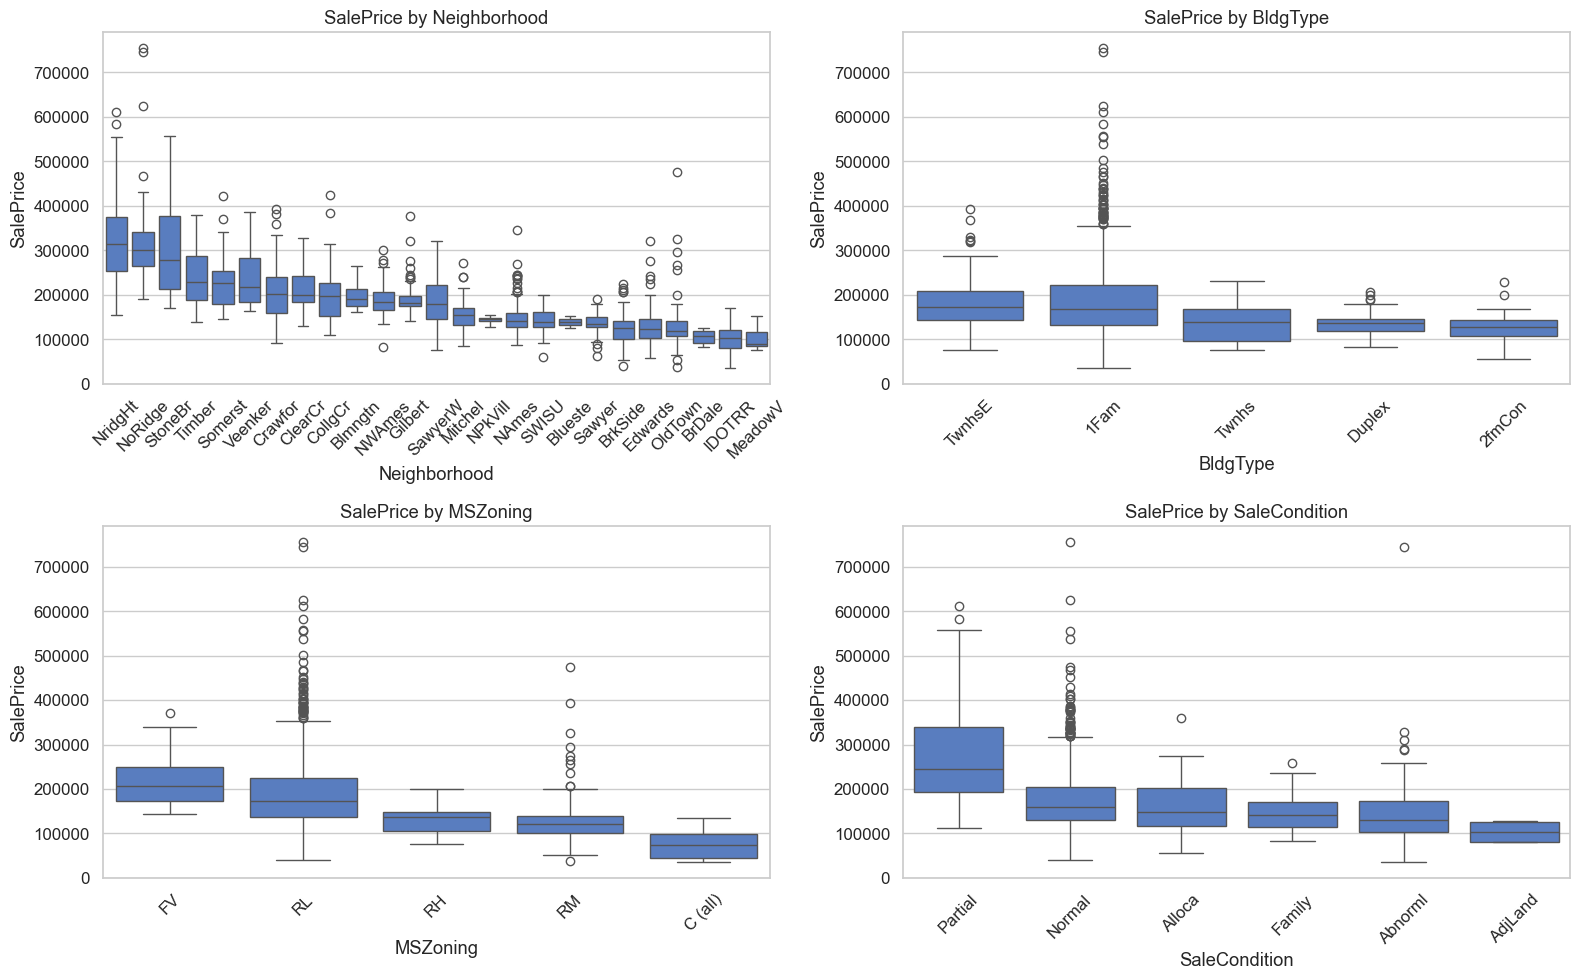

In [12]:
cat_features_eda = ['Neighborhood', 'BldgType', 'MSZoning', 'SaleCondition']

fig, axes = plt.subplots(2,2,figsize=(16,10))

for ax,feat in zip(axes.ravel(), cat_features_eda):
    order = data.groupby(feat)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=feat, y='SalePrice', data=data, order=order, ax= ax)
    ax.set_title(f"SalePrice by {feat}")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**EDA Summary:**
- `OverallQual` and `GrLivArea` are the strongest numeric predictors.
- Garage capacity, basement size, and year built are also highly correlated.
- Neighbourhood has a large effect on price, with `NoRidge`, `NridgHt`, and `StoneBr` at the top.
- A few outliers with very large `GrLivArea` but low `SalePrice` may need attention.

---

### 3 - PreProcessing & Base Modeling

#### 3.1 Feature / Target Split and Train Test Split

In [13]:
data_model = data.drop(columns='Id')
# X features
X = data_model.drop(columns='SalePrice')
# Y target
y = data_model['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"X Train: {len(X_train)} and XTest: {len(X_test)}")
print(f"Y_Train: {len(y_train)} and YTest: {len(y_test)}")

print(f"X Train shape: {X_train.shape} and X Test Shape: {X_test.shape}")
print(f"Y Train shape: {y_train.shape} and Y Test Shape: {y_test.shape}")


X Train: 1168 and XTest: 292
Y_Train: 1168 and YTest: 292
X Train shape: (1168, 79) and X Test Shape: (292, 79)
Y Train shape: (1168,) and Y Test Shape: (292,)


### 3.2 Identify Numeric and Categorical Columns

In [14]:
numerical_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numeric features   : {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')


Numeric features   : 36
Categorical features: 43


#### handle_unknown='ignore'
- Prevents errors when new/unseen categories appear during testing or deployment.

#### sparse_output=False
- Controls output format of encoded data

#### 3.3 Preprocessing Pipeline

In [15]:
numerical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Preprocessing Pipeline is defined ....... ")

Preprocessing Pipeline is defined ....... 


#### 3.4 BaseLine Modeling

In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle(y_true, y_pred):
    y_pred_clip = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

def evaluate_model(name, pipeline, X_tr, y_tr, X_test, y_test, result):
    pipeline.fit(X_tr, y_tr)
    y_pred_train = pipeline.predict(X_tr)
    y_pred_test = pipeline.predict(X_test)

    cv_score = cross_val_score(pipeline, X_tr, y_tr, cv = 5, scoring='neg_root_mean_squared_error')

    cv_rmse = -cv_score.mean()
    cv_std = cv_score.std()

    tr_rmse = rmse(y_tr, y_pred_train)
    test_rmse = rmse(y_test, y_pred_test)
    test_rmsle_val = rmsle(y_test, y_pred_test)

    result.append({
        'Model': name,
        'Train RMSE': round(tr_rmse, 2),
        'Test RMSE': round(test_rmse, 2),
        'CV RMSE (mean±std)': f'{cv_rmse:,.0f} + {cv_std:,.0f}',
        'Test RMSLE': round(test_rmsle_val, 2)
    })

    print(f"{name:30s} Train RMSE={tr_rmse:>10,.0f}  Test RMSE={test_rmse:>10,.0f}  CV RMSE={cv_rmse:>10,.0f}')")
    return pipeline

In [17]:
result = []

base_models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge(Alpha = 10)'  : Ridge(alpha=10, random_state=SEED),
    'Lasso(Alpha = 100)' : Lasso(alpha=100, max_iter=10000, random_state=SEED),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=6, random_state=SEED)
}

fitted_pipelines = {}
for name, model in base_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, result)

pd.DataFrame(result)

Linear Regression              Train RMSE=    18,904  Test RMSE=    65,385  CV RMSE=    43,614')
Ridge(Alpha = 10)              Train RMSE=    24,359  Test RMSE=    30,521  CV RMSE=    32,637')
Lasso(Alpha = 100)             Train RMSE=    22,001  Test RMSE=    28,225  CV RMSE=    33,052')
Decision Tree                  Train RMSE=    23,014  Test RMSE=    42,126  CV RMSE=    44,335')


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18904.11,65385.32,"43,614 + 16,218",0.72
1,Ridge(Alpha = 10),24358.84,30520.93,"32,637 + 9,407",0.16
2,Lasso(Alpha = 100),22000.55,28224.65,"33,052 + 8,813",0.15
3,Decision Tree,23013.61,42126.22,"44,335 + 10,165",0.21


### 4 - Advanced Models and Feature Engineering

#### 4.1 Advance models(Hyper Parameters)

In [18]:
advanced_model = {
    'Random Forest' : RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=300,  max_depth = 4, random_state=SEED, learning_rate=0.1),
    'XG Boosting' : XGBRegressor(n_estimator=300, learning_rate=0.1, random_state=SEED, max_depth = 4, verbosity=0, n_jobs=-1),
}

for name, model in advanced_model.items():
    pipe = Pipeline([('preprocessor', preprocessor),('model', model)])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, result)

pd.DataFrame(result)

Random Forest                  Train RMSE=    11,129  Test RMSE=    29,229  CV RMSE=    30,625')
Gradient Boosting              Train RMSE=     4,661  Test RMSE=    26,551  CV RMSE=    29,830')
XG Boosting                    Train RMSE=    10,397  Test RMSE=    25,927  CV RMSE=    29,403')


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18904.11,65385.32,"43,614 + 16,218",0.72
1,Ridge(Alpha = 10),24358.84,30520.93,"32,637 + 9,407",0.16
2,Lasso(Alpha = 100),22000.55,28224.65,"33,052 + 8,813",0.15
3,Decision Tree,23013.61,42126.22,"44,335 + 10,165",0.21
4,Random Forest,11128.55,29228.64,"30,625 + 4,733",0.15
5,Gradient Boosting,4661.50,26551.09,"29,830 + 4,476",0.14
6,XG Boosting,10397.30,25926.63,"29,403 + 4,518",0.14


## 4.2 feature Engineering
Adding domain specific features and adding log to the skewed data

In [19]:
def add_features(data):
    copy_data = data.copy()
    copy_data['Total_SF' ] = copy_data['TotalBsmtSF'] + copy_data['1stFlrSF'] + copy_data['2ndFlrSF']
    copy_data['TotalBath'] = (copy_data['FullBath'] + 0.5 * copy_data['HalfBath']
                          + copy_data['BsmtFullBath'] + 0.5 * copy_data['BsmtHalfBath'])
    copy_data['TotalPorchSF'] = (copy_data['OpenPorchSF'] + copy_data['EnclosedPorch']
                              + copy_data['3SsnPorch'] + copy_data['ScreenPorch'])
    copy_data['HouseAge'] = copy_data['YrSold'] - copy_data['YearBuilt']
    copy_data['ReModAge'] = copy_data['YrSold'] - copy_data['YearRemodAdd']
    copy_data['HasGarage'] = (copy_data['GarageArea'] > 0).astype(int)
    copy_data['HasBsmt'] = (copy_data['TotalBsmtSF'] > 0).astype(int)
    copy_data['Has2ndFlr'] = (copy_data['2ndFlrSF'] > 0).astype(int)
    copy_data['HasPool'] = (copy_data['PoolArea'] > 0).astype(int)
    return copy_data

X_train_fe =  add_features(X_train)
X_test_fe = add_features(X_test)


numerical_feature_fe = X_train_fe.select_dtypes(include='number').columns.tolist()
categorical_feature_fe = X_train_fe.select_dtypes(include='object').columns.tolist()

preprocessor_fe = ColumnTransformer([
    ('num', numerical_transformer, numerical_feature_fe),
    ('cat', categorical_transformer, categorical_feature_fe)
])

print(f'Engineered feature set: {X_train_fe.shape[1]} features ({len(numerical_feature_fe)} num, {len(categorical_feature_fe)} cat)')

Engineered feature set: 88 features (45 num, 43 cat)


### Feature Selection via Lasso
Lasso can be used for feature selection and it makes the important feature point to be highest and other features to = 0

In [20]:
lasso_model = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', Lasso(alpha=50, random_state=SEED, max_iter=10000))
])

lasso_model.fit(X_train_fe, y_train)

ohe_names = lasso_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_feature_fe)
all_feat_names = np.array(numerical_feature_fe + list(ohe_names))
lasso_coefs = lasso_model.named_steps['model'].coef_
nonzero = np.sum(lasso_coefs != 0)
print(f'Lasso kept {nonzero} / {len(lasso_coefs)} features (alpha=50)')

Lasso kept 149 / 310 features (alpha=50)


### 4.3 Re-Train advance models with engineered features

In [21]:
fe_models = {
    'Ridge + Fe' : Ridge(alpha=10, random_state=SEED),
    'Random Forest + FE' : RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    'Gradient Descent + FE' : GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=4, random_state=SEED),
    'XGBoost + FE' : XGBRegressor(n_estimators=300, verbosity=0 ,learning_rate=0.1, max_depth=4, n_jobs = -1, random_state=SEED)
}

for name, model in fe_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_fe),
        ('model', model)
    ])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train_fe, y_train, X_test_fe, y_test, result)

pd.DataFrame(result)

Ridge + Fe                     Train RMSE=    23,888  Test RMSE=    30,080  CV RMSE=    32,575')
Random Forest + FE             Train RMSE=    10,813  Test RMSE=    29,187  CV RMSE=    29,583')
Gradient Descent + FE          Train RMSE=     4,304  Test RMSE=    27,817  CV RMSE=    27,778')
XGBoost + FE                   Train RMSE=     5,366  Test RMSE=    25,510  CV RMSE=    29,011')


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18904.11,65385.32,"43,614 + 16,218",0.72
1,Ridge(Alpha = 10),24358.84,30520.93,"32,637 + 9,407",0.16
2,Lasso(Alpha = 100),22000.55,28224.65,"33,052 + 8,813",0.15
3,Decision Tree,23013.61,42126.22,"44,335 + 10,165",0.21
4,Random Forest,11128.55,29228.64,"30,625 + 4,733",0.15
5,Gradient Boosting,4661.50,26551.09,"29,830 + 4,476",0.14
6,XG Boosting,10397.30,25926.63,"29,403 + 4,518",0.14
7,Ridge + Fe,23888.02,30080.05,"32,575 + 9,822",0.16
8,Random Forest + FE,10812.79,29186.62,"29,583 + 4,520",0.15
9,Gradient Descent + FE,4303.87,27817.47,"27,778 + 3,523",0.14


### 4.5 Hyper Tuning (XG Boost + FE)


In [22]:
xgb_pipe = Pipeline([('preprocessor', preprocessor_fe),('model',XGBRegressor(verbosity=0,random_state = SEED, n_jobs = -1))])

param_grid = {
    'model__n_estimators': [500, 600],
    'model__max_depth': [5, 6, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb_pipe, param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_fe, y_train)

print(f'\nBest CV RMSE: {-grid_search.best_score_:,.0f}')
print(f'Best params : {grid_search.best_params_}')


Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best CV RMSE: 27,318
Best params : {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 500, 'model__subsample': 0.8}


In [23]:
best_pipe = grid_search.best_estimator_
fitted_pipelines['XGBoost Tuned + FE'] = evaluate_model(
    'XGBoost Tuned + FE', best_pipe,
    X_train_fe, y_train, X_test_fe, y_test, result
)

pd.DataFrame(result)

XGBoost Tuned + FE             Train RMSE=       672  Test RMSE=    26,049  CV RMSE=    29,205')


,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18904.11,65385.32,"43,614 + 16,218",0.72
1,Ridge(Alpha = 10),24358.84,30520.93,"32,637 + 9,407",0.16
2,Lasso(Alpha = 100),22000.55,28224.65,"33,052 + 8,813",0.15
3,Decision Tree,23013.61,42126.22,"44,335 + 10,165",0.21
4,Random Forest,11128.55,29228.64,"30,625 + 4,733",0.15
5,Gradient Boosting,4661.50,26551.09,"29,830 + 4,476",0.14
6,XG Boosting,10397.30,25926.63,"29,403 + 4,518",0.14
7,Ridge + Fe,23888.02,30080.05,"32,575 + 9,822",0.16
8,Random Forest + FE,10812.79,29186.62,"29,583 + 4,520",0.15
9,Gradient Descent + FE,4303.87,27817.47,"27,778 + 3,523",0.14


---
### 5 - Model Evaluation and Communication


### Model Comparison table

In [24]:
results_df = pd.DataFrame(result)
display(results_df.style.highlight_min(subset=['Test RMSE', 'Test RMSLE'], color='#d4edda'))

,Model,Train RMSE,Test RMSE,CV RMSE (mean±std),Test RMSLE
0,Linear Regression,18904.110000,65385.320000,"43,614 + 16,218",0.720000
1,Ridge(Alpha = 10),24358.840000,30520.930000,"32,637 + 9,407",0.160000
2,Lasso(Alpha = 100),22000.550000,28224.650000,"33,052 + 8,813",0.150000
3,Decision Tree,23013.610000,42126.220000,"44,335 + 10,165",0.210000
4,Random Forest,11128.550000,29228.640000,"30,625 + 4,733",0.150000
5,Gradient Boosting,4661.500000,26551.090000,"29,830 + 4,476",0.140000
6,XG Boosting,10397.300000,25926.630000,"29,403 + 4,518",0.140000
7,Ridge + Fe,23888.020000,30080.050000,"32,575 + 9,822",0.160000
8,Random Forest + FE,10812.790000,29186.620000,"29,583 + 4,520",0.150000
9,Gradient Descent + FE,4303.870000,27817.470000,"27,778 + 3,523",0.140000


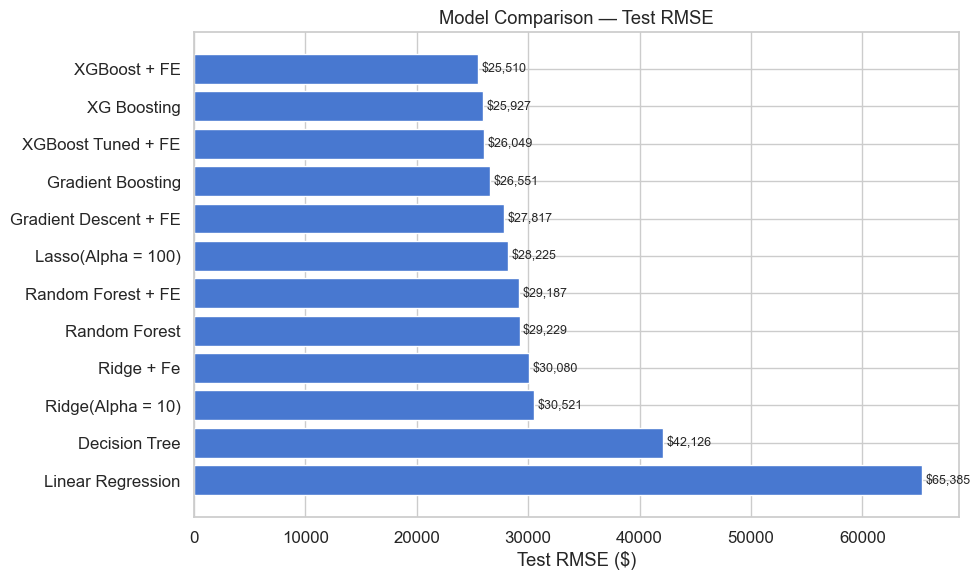

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
results_df_sorted = results_df.sort_values('Test RMSE')
bars = ax.barh(results_df_sorted['Model'], results_df_sorted['Test RMSE'])
ax.set_xlabel('Test RMSE ($)')
ax.set_title('Model Comparison — Test RMSE')
ax.invert_yaxis()
for bar, val in zip(bars, results_df_sorted['Test RMSE']):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Choosing best model

Best model by Test RMSE: XGBoost + FE


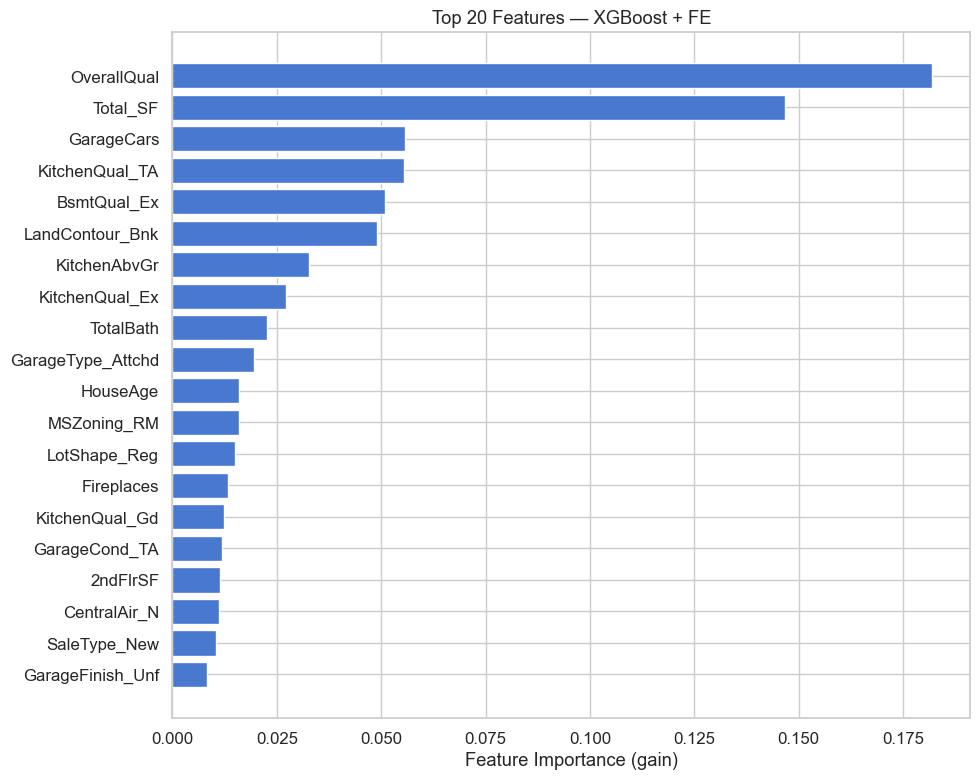

In [27]:
best_model_name = results_df.loc[results_df['Test RMSE'].idxmin(), 'Model']
print(f'Best model by Test RMSE: {best_model_name}')

best_model_pipe = fitted_pipelines[best_model_name]
model_obj = best_model_pipe.named_steps['model']

if best_model_name.startswith('XGBoost'):
    use_fe = 'FE' in best_model_name
    pre = best_model_pipe.named_steps['preprocessor']
    if use_fe:
        ohe_out = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_feature_fe)
        feat_names = np.array(list(numerical_feature_fe) + list(ohe_out))
    else:
        ohe_out = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
        feat_names = np.array(list(numerical_cols) + list(ohe_out))

    importances = model_obj.feature_importances_
    imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(imp_df['Feature'], imp_df['Importance'])
    ax.set_xlabel('Feature Importance (gain)')
    ax.set_title(f'Top 20 Features — {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### 5.3 Ridge Coefficients (Linear Model Interpretation)

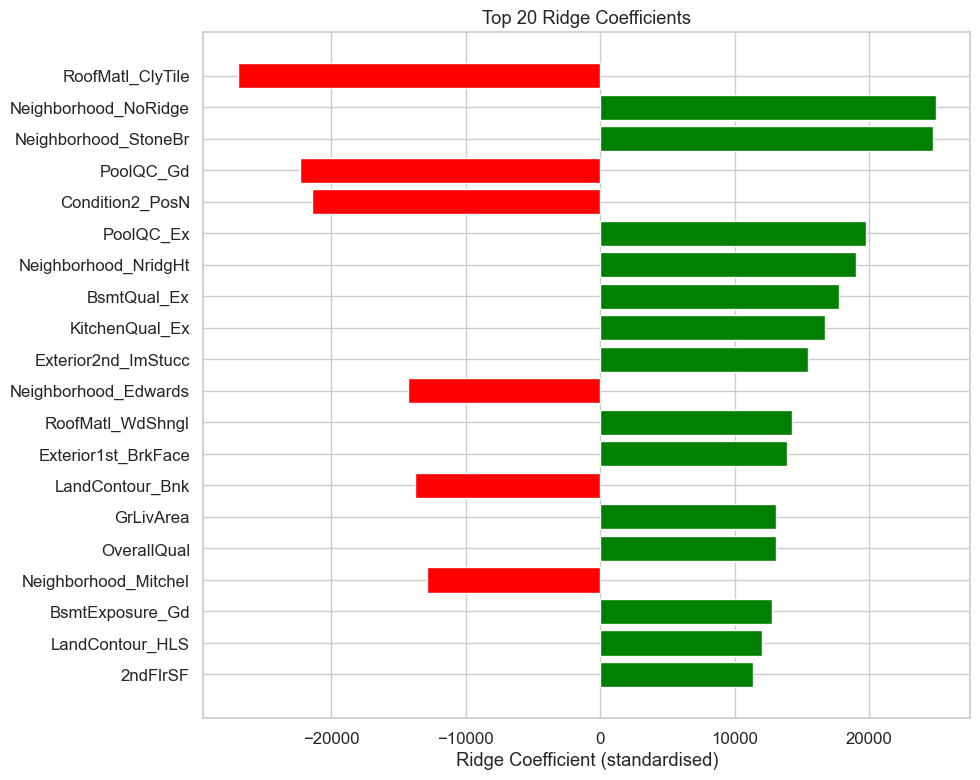

In [30]:
use_fe_ridge = 'Ridge + FE' in fitted_pipelines
ridge_pipe = fitted_pipelines['Ridge + Fe'] if use_fe_ridge else fitted_pipelines['Ridge(Alpha = 10)']
ridge_model = ridge_pipe.named_steps['model']
pre_ridge = ridge_pipe.named_steps['preprocessor']

if use_fe_ridge:
    ohe_out_r = pre_ridge.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_feature_fe)
    feat_names_r = np.array(list(numerical_feature_fe) + list(ohe_out_r))
else:
    ohe_out_r = pre_ridge.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    feat_names_r = np.array(list(numerical_cols) + list(ohe_out_r))

coef_df = pd.DataFrame({'Feature': feat_names_r, 'Coefficient': ridge_model.coef_})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_xlabel('Ridge Coefficient (standardised)')
ax.set_title('Top 20 Ridge Coefficients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

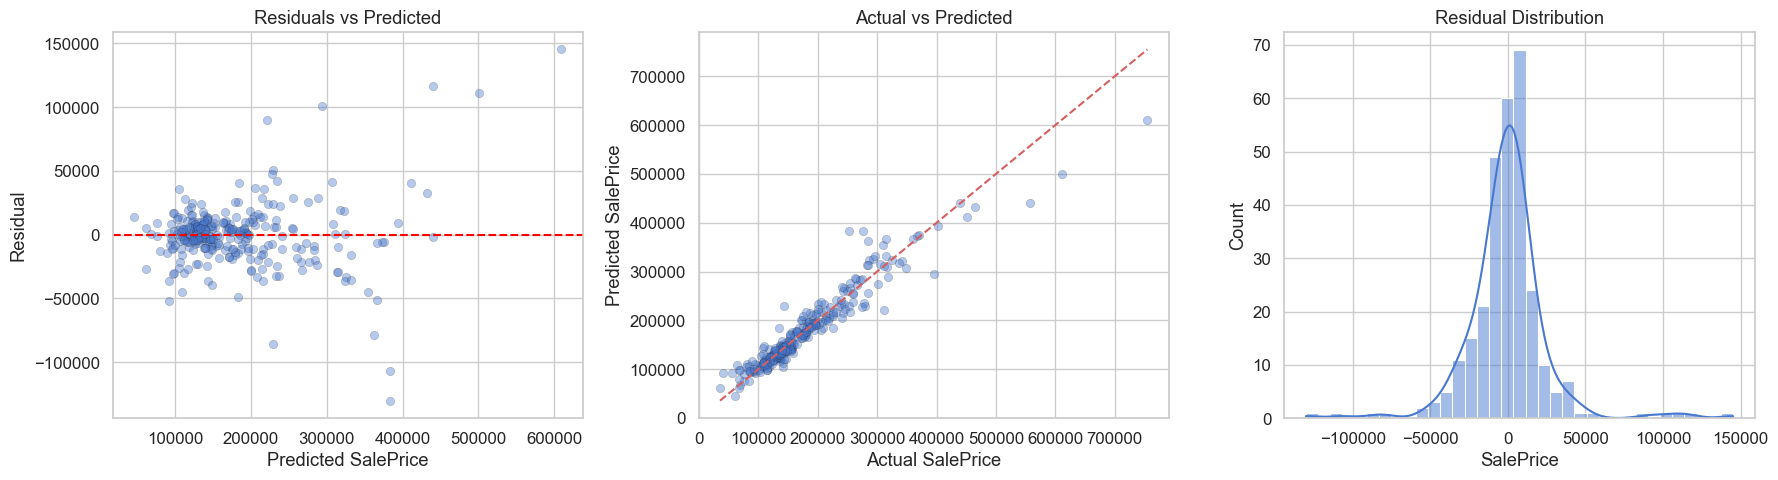

In [31]:
y_pred_best = best_model_pipe.predict(X_test_fe if 'FE' in best_model_name else X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual SalePrice')
axes[1].set_ylabel('Predicted SalePrice')
axes[1].set_title('Actual vs Predicted')

sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

In [32]:
error_df = X_test.copy()
if 'FE' in best_model_name:
    error_df = X_test_fe.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred_best
error_df['Residual'] = residuals.values
error_df['AbsError'] = np.abs(residuals.values)
error_df['PctError'] = (error_df['AbsError'] / error_df['Actual'] * 100).round(1)

print('=== 10 Worst Predictions (by absolute error) ===')
worst = error_df.nlargest(10, 'AbsError')[['Actual', 'Predicted', 'Residual', 'AbsError', 'PctError',
                                            'OverallQual', 'GrLivArea', 'Neighborhood', 'YearBuilt']]
display(worst)

=== 10 Worst Predictions (by absolute error) ===


,Actual,Predicted,Residual,AbsError,PctError,OverallQual,GrLivArea,Neighborhood,YearBuilt
691,755000,609732.812500,145267.187500,145267.187500,19.2,10,4316,NoRidge,1994
581,253293,383473.406250,-130180.406250,130180.406250,51.4,8,2042,NridgHt,2008
1046,556581,440052.593750,116528.406250,116528.406250,20.9,9,2868,StoneBr,2005
898,611657,500658.781250,110998.218750,110998.218750,18.1,9,2364,NridgHt,2009
261,276000,383194.125000,-107194.125000,107194.125000,38.8,8,2574,CollgCr,2007
774,395000,294270.843750,100729.156250,100729.156250,25.5,8,1973,NridgHt,2006
218,311500,221761.109375,89738.890625,89738.890625,28.8,7,1954,Crawfor,1939
588,143000,228903.328125,-85903.328125,85903.328125,60.1,5,1473,ClearCr,1968
332,284000,362485.937500,-78485.937500,78485.937500,27.6,8,1629,NridgHt,2003
30,40000,91816.906250,-51816.906250,51816.906250,129.5,4,1317,IDOTRR,1920


**Error Analysis Observations:**
- Residuals are roughly centred around zero, with slightly heavier tails for expensive homes.
- The worst predictions tend to be unusual properties — very large living area, older homes sold at a premium, or atypical sale conditions.
- The model systematically under-predicts the most expensive homes; adding more neighbourhood-level features or treating top-end homes separately could help.

---
## 6 — Conclusions

1. **Best model:** The XGBoost + FE with engineered features achieved the lowest test RMSE, demonstrating that gradient boosting combined with domain-driven features is most effective for this dataset.
2. **Key predictors:** Overall quality, living area, total square footage, garage capacity, and neighbourhood are the strongest drivers of sale price.
3. **Feature engineering impact:** Adding composite features (TotalSF, TotalBath, HouseAge) consistently improved all model families.
4. **Potential improvements:**
   - Target-encode high-cardinality categoricals instead of one-hot encoding.
   - Stack or blend the best tree-based and linear models.
   - Remove or cap outliers (e.g., GrLivArea > 4000 with low SalePrice).
   - Explore ordinal encoding for quality features with natural order.